### Import Required Library

In [63]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

## Data Overview

In [3]:
df = pd.read_csv('../data/train.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [21]:
(df.isnull().mean() * 100).sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

77% Cabin is null, so i'll drop it later

### Data Visualization

In [48]:
sns.set_palette('mako')

<Axes: xlabel='Pclass', ylabel='Survived'>

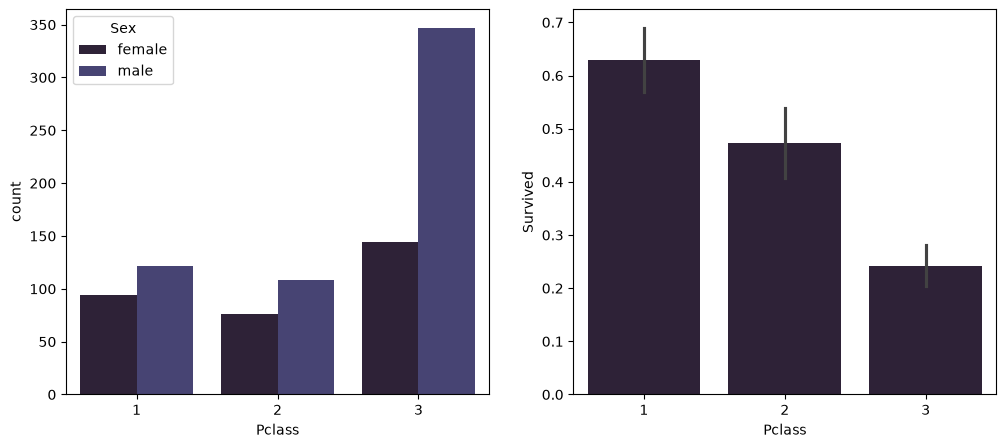

In [56]:
# check pclass column 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x='Pclass', hue='Sex', data=df, ax=ax1)
sns.barplot(x="Pclass", y="Survived", data=df)

Text(0.5, 1.0, 'Fare Distribution')

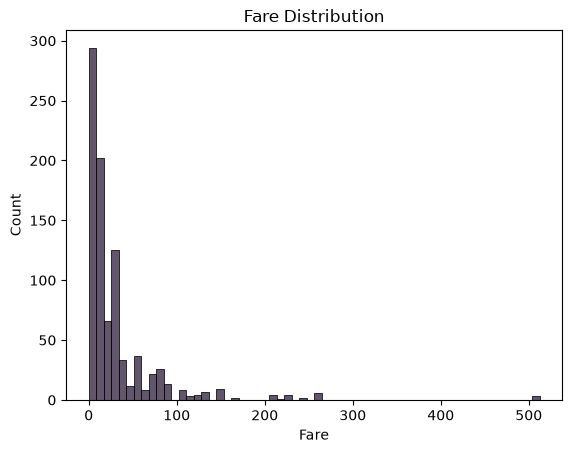

In [62]:
sns.histplot(x='Fare', data=df).set_title('Fare Distribution')

<Axes: xlabel='LogFare', ylabel='Count'>

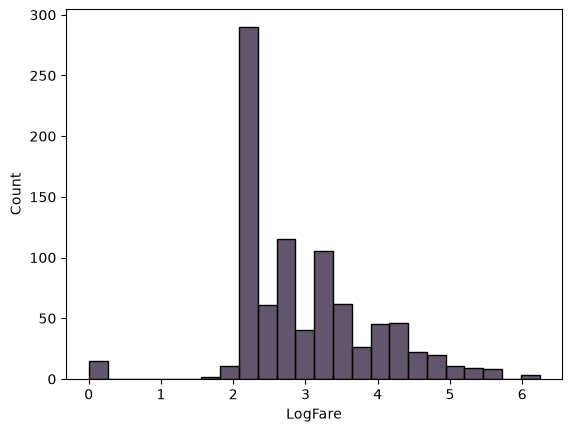

In [64]:
df['LogFare'] = np.log1p(df['Fare'])
sns.histplot(x='LogFare', data=df)

<Axes: xlabel='Survived', ylabel='Age'>

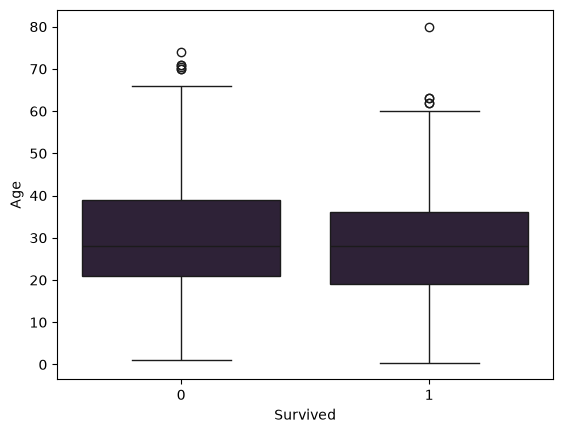

In [68]:
# age
sns.boxplot(data=df, x="Survived", y="Age")

In [69]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

<Axes: xlabel='FamilySize', ylabel='Survived'>

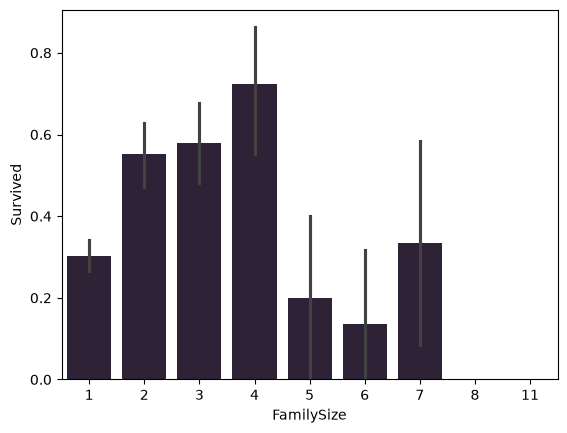

In [73]:
sns.barplot(x='FamilySize', y='Survived', data=df)

In [74]:
df["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64